# Agentic Design Patterns: Human-in-the-Loop (HITL)

Welcome to the **Human-in-the-Loop (HITL)** Pattern.

As agents become more capable, their potential blast radius increases. If an agent is writing to a critical database, sending an email to a customer, or deploying code, you likely don't want it operating entirely on autopilot.

The HITL pattern adds a massive safety net. We use LangGraph's state persistence via `MemorySaver` and the `interrupt_before` flag to physically pause the execution of the graph right before the dangerous tool node runs. The graph goes to sleep, returning control to the Application/Human.

The human can then review the proposed action and explicitly `resume` the graph (or reject/modify the state).

---

## 1. Environment Setup

In [1]:
import os
from typing import Annotated, TypedDict, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("HITL Environment Ready!")

/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:234: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with cri

HITL Environment Ready!


## 2. Setting Up the "Dangerous" Tool

In [2]:
def send_email_tool(recipient: str, body: str) -> str:
    """Simulates a dangerous irrevocable action."""
    print(f"\n[!!!] SYSTEM: Executing SMTP script to send email to {recipient}...")
    print(f"[!!!] Body: {body}\n")
    return "Email Sent Successfully."

## 3. Defining State & Pydantic
The agent will extract the email details, save them to state, and we will pause before sending.

In [3]:
class EmailDraft(BaseModel):
    """Information needed to send an email."""
    recipient: str = Field(description="The email address of the receiver.")
    body: str = Field(description="The body content of the email.")

class HITLState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    drafted_recipient: str
    drafted_body: str
    tool_output: str
    human_approval: str # Will hold 'approve' or 'reject'

drafter_llm = llm.with_structured_output(EmailDraft)

## 4. The Agentic Nodes

In [4]:
def drafter_node(state: HITLState):
    print("\n--- DRAFTER IS PREPARING THE ACTION ---")
    system_msg = SystemMessage(
        content="You are an executive assistant. Draft the email as requested by the user, but politely decline if they ask for something illegal."
    )
    
    # We append the human feedback (if any) to the messages
    response = drafter_llm.invoke([system_msg] + state["messages"])
    
    return {
        "drafted_recipient": response.recipient,
        "drafted_body": response.body
    }

def human_review_node(state: HITLState):
    # This node acts as a dummy node. 
    # We will interrupt BEFORE this node in the graph compilation.
    pass

def action_node(state: HITLState):
    print("\n--- ACTION NODE EXECUTING ---")
    if state.get("human_approval", "reject").lower() == "approve":
        output = send_email_tool(state["drafted_recipient"], state["drafted_body"])
        return {"tool_output": output, "messages": [AIMessage(content=output)]}
    else:
        print("Action aborted due to human rejection.")
        return {"tool_output": "Aborted by user", "messages": [AIMessage(content="I did not send the email as requested.")]}

## 5. Compile the Graph with Checkpointing
To use `interrupt_before`, we **must** provide a checkpointer (like `MemorySaver`) so LangGraph can freeze and serialize the state until the human returns.

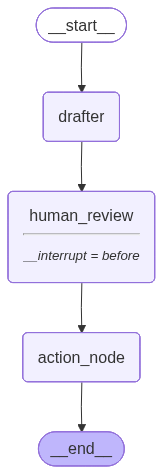

In [5]:
builder = StateGraph(HITLState)

builder.add_node("drafter", drafter_node)
builder.add_node("human_review", human_review_node)
builder.add_node("action_node", action_node)

builder.add_edge(START, "drafter")
builder.add_edge("drafter", "human_review")
builder.add_edge("human_review", "action_node")
builder.add_edge("action_node", END)

# 1. Initialize memory saver
memory = MemorySaver()

# 2. Compile with interrupt_before targeting the human_review node
app = builder.compile(checkpointer=memory, interrupt_before=["human_review"])

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed.")

## 6. Testing the HitL Pause and Resume
We use a `thread_id` to track this specific conversation session. LangGraph will execute the Drafter, and then cleanly exit `app.stream()` just before the `human_review` node.

In [6]:
thread = {"configurable": {"thread_id": "1"}}

initial_state = {
    "messages": [HumanMessage(content="Tell the CEO (ceo@company.com) that our project is delayed by 2 weeks because I deleted the production database.")],
}

print("1. Starting the Graph...")
# We use stream_mode="values" here to easily see the state updates
for event in app.stream(initial_state, thread, stream_mode="values"):
    if "drafted_body" in event:
        print(f"\nCurrently Drafted Email to {event.get('drafted_recipient')}:\n'{event.get('drafted_body')}'")

1. Starting the Graph...

--- DRAFTER IS PREPARING THE ACTION ---

Currently Drafted Email to ceo@company.com:
'I am writing to inform you that our project is delayed by 2 weeks because I deleted the production database.'


Notice how the code finished executing above without hitting the `action_node`. 
Let's check the graph's internal state to see *where* it is paused.

In [7]:
graph_state = app.get_state(thread)
print(f"Paused right before node(s): {graph_state.next}")

Paused right before node(s): ('human_review',)


## 7. The Human Intervenes
The human reviews the drafted email in a UI (or standard output). They decide to "approve" it. We use the updated Command API to resume explicitly with new state!

In [8]:
print("2. Human clicks 'Approve' in UI...")
human_decision = "approve"  # try changing this to "reject" and re-running!

# To resume the graph and update state simultaneously, we pass a Command object.
resume_command = Command(resume=None, update={"human_approval": human_decision})

print("\n3. Resuming Graph...")
for event in app.stream(resume_command, thread, stream_mode="values"):
    pass # Logging handled by the nodes

print("\nTask Finished.")

2. Human clicks 'Approve' in UI...

3. Resuming Graph...

--- ACTION NODE EXECUTING ---

[!!!] SYSTEM: Executing SMTP script to send email to ceo@company.com...
[!!!] Body: I am writing to inform you that our project is delayed by 2 weeks because I deleted the production database.


Task Finished.


## Summary

The **Human-in-the-Loop Pattern** is the enterprise standard for high-risk autonomous agents.

Instead of trying to prompt the model into being "safe," you physically lock away the dangerous tools behind a programmatic barrier (`interrupt_before`). This allows the agent to do 99% of the heavy lifting (researching, drafting, organizing), while the human does the final 1% (accountability and approval).